In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the perfectly clean, engineered data from Week 2
df = pd.read_csv('../../data/engineered_earthquake_data.csv')

# 2. Create the Target Variable
# We still use the median to ensure we have a balanced 50/50 split of High/Low risk
threshold = df['magnitude'].median()
print(f"Dividing 'High Risk' and 'Low Risk' at Magnitude: {threshold}")

df['High_Risk'] = (df['magnitude'] >= threshold).astype(int)

# 3. Define Features (X) and Target (y)
# Notice how we are now using the upgraded features from Week 2!
features = ['depth_scaled', 'latitude', 'longitude', 'location_risk_score']
X = df[features]
y = df['High_Risk']

print("Target Class Distribution:")
print(y.value_counts())

Dividing 'High Risk' and 'Low Risk' at Magnitude: 6.8
Target Class Distribution:
High_Risk
1    438
0    344
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 625 rows
Testing set size: 157 rows


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predict and evaluate
log_preds = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_preds)

print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 46.50%


In [4]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
tree_preds = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_preds)

print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 57.32%


C:\Users\acer\AppData\Local\Temp\ipykernel_7652\2496221488.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


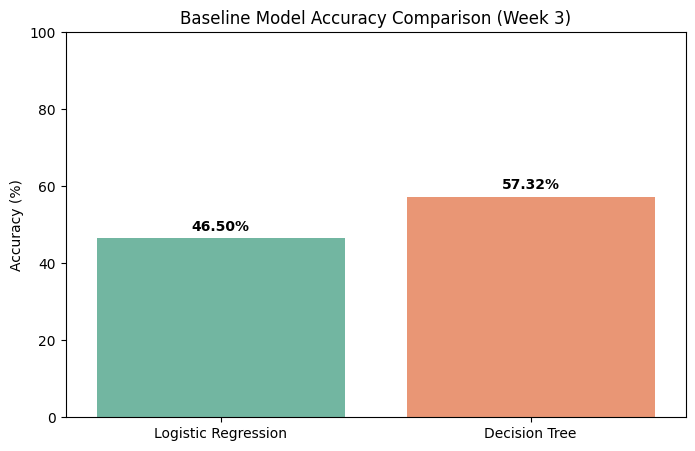

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Store our model names and their scores
models = ['Logistic Regression', 'Decision Tree']
accuracies = [log_accuracy * 100, tree_accuracy * 100]

# Create a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='Set2')

# Add labels and title
plt.title('Baseline Model Accuracy Comparison (Week 3)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Keep Y-axis from 0 to 100%

# Display the exact numbers on top of the bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

In [6]:
# Cell 6: MAE Analysis for Baseline Models (Fulfilling Week 3 Rubric)
from sklearn.metrics import mean_absolute_error

# Calculate MAE for Logistic Regression
log_mae = mean_absolute_error(y_test, log_preds)

# Calculate MAE for Decision Tree
tree_mae = mean_absolute_error(y_test, tree_preds)

print("--- Baseline MAE Analysis ---")
print(f"Logistic Regression MAE: {log_mae:.4f}")
print(f"Decision Tree MAE: {tree_mae:.4f}")
print("(Note: Because this is a binary classification (0 or 1), the MAE represents the exact percentage of misclassified predictions).")

--- Baseline MAE Analysis ---
Logistic Regression MAE: 0.5350
Decision Tree MAE: 0.4268
(Note: Because this is a binary classification (0 or 1), the MAE represents the exact percentage of misclassified predictions).
